# AI Zero to Hero: End of Course Practical Assessment
## Practical Data Analysis: EDA, Predictive Modelling, and Hierarchical Clustering

Welcome to the end-of-course practical assessment! In this notebook, you will apply the concepts learned across the course using Python in Google Colab.

### Objectives:
1. **Mount Google Drive** and prepare your environment.
2. Perform **Exploratory Data Analysis (EDA)** on a diabetes health metrics dataset.
3. Build and evaluate **Predictive Regression and Classification Models**.
4. Apply **Hierarchical Agglomerative Clustering** and interpret dendrograms.

---

## Task 0: Setup and Mount Google Drive
Run the cell below to load the required Python libraries and mount your Google Drive.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Set up assessment folder
assessment_folder = 'outputs'
os.makedirs(assessment_folder, exist_ok=True)
print("Setup complete. Saving folder initialized at:", assessment_folder)

Setup complete. Saving folder initialized at: outputs


---
# Section 1: Exploratory Data Analysis (EDA)

We will be working with the **Diabetes Dataset**, which tracks ten physiological baseline variables (age, sex, BMI, blood pressure, and blood serum measurements s1–s6) and a quantitative measure of disease progression standard score.
Below, we load the dataset into a Pandas DataFrame.

In [2]:
# Load dataset
diabetes_raw = load_diabetes(as_frame=True)
df = diabetes_raw.frame.copy()

# Display first few rows
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### Code Example 1.1: Calculating Summary Statistics
Here is how we calculate the mean, standard deviation, and summary statistics for the `bmi` (Body Mass Index) feature:

In [3]:
mean_bmi = df['bmi'].mean()
std_bmi = df['bmi'].std()
print(f"BMI - Mean: {mean_bmi:.4f}, SD: {std_bmi:.4f}")
df[['bmi']].describe()

BMI - Mean: -0.0000, SD: 0.0476


,bmi
count,4.420000e+02
mean,-2.245564e-16
std,4.761905e-02
min,-9.027530e-02
25%,-3.422907e-02
50%,-7.283766e-03
75%,3.124802e-02
max,1.705552e-01


### ✏️ Exercise 1.1
Modify the code below to calculate the mean, standard deviation, and summary statistics for the **`bp`** (average blood pressure) variable instead of `bmi`.

In [4]:
# --- YOUR CODE HERE ---
# Change 'bmi' to 'bp'
mean_bp = df['bmi'].mean()
std_bp = df['bmi'].std()
print(f"Blood Pressure - Mean: {mean_bp:.4f}, SD: {std_bp:.4f}")
df[['bmi']].describe()

Blood Pressure - Mean: -0.0000, SD: 0.0476


,bmi
count,4.420000e+02
mean,-2.245564e-16
std,4.761905e-02
min,-9.027530e-02
25%,-3.422907e-02
50%,-7.283766e-03
75%,3.124802e-02
max,1.705552e-01


### Code Example 1.2: Scatter Plots and Saving Figures
We can explore relationships between physiological features and disease progression using scatter plots and save them to Google Drive.

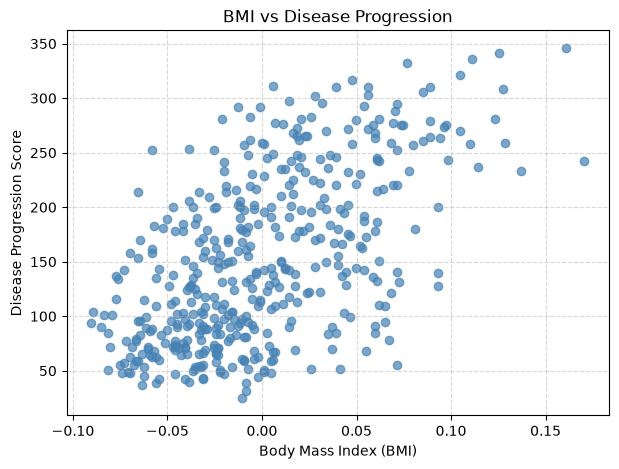

Figure saved to: outputs\bmi_vs_progression.png


In [5]:
plt.figure(figsize=(7, 5))
plt.scatter(df['bmi'], df['target'], color='steelblue', alpha=0.7)
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Disease Progression Score')
plt.title('BMI vs Disease Progression')
plt.grid(True, linestyle='--', alpha=0.5)

# Save plot
fig_path = os.path.join(assessment_folder, 'bmi_vs_progression.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved to:', fig_path)

### ✏️ Exercise 1.2
Alter the code below to plot **`s5`** (blood serum measurement 5) on the X-axis and **`target`** on the Y-axis. Change the point color to `'coral'` and save the figure as `'s5_vs_progression.png'`.

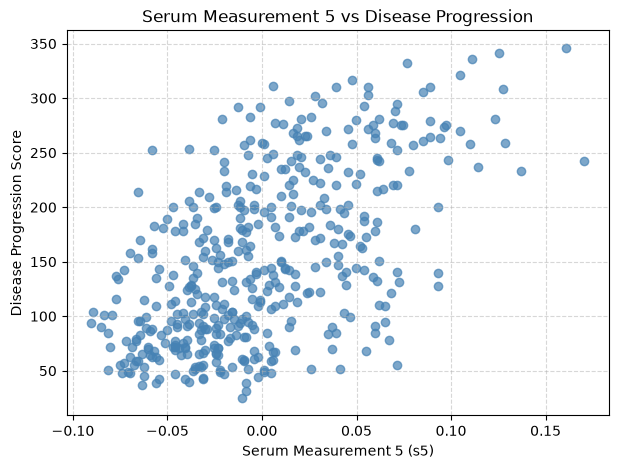

In [6]:
# --- YOUR CODE HERE ---
plt.figure(figsize=(7, 5))
plt.scatter(df['bmi'], df['target'], color='steelblue', alpha=0.7) # Modify X, Y, and color
plt.xlabel('Serum Measurement 5 (s5)')
plt.ylabel('Disease Progression Score')
plt.title('Serum Measurement 5 vs Disease Progression')
plt.grid(True, linestyle='--', alpha=0.5)

fig_path = os.path.join(assessment_folder, 'bmi_vs_progression.png') # Update filename
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

---
# Section 2: Predictive Modelling

## 2.1 Regression
Suppose we want to predict the continuous **`target`** (disease progression measure) based on patient health indicators.

In [7]:
# Target continuous variable
y_reg = df['target']

# Feature: BMI
X_reg1 = df[['bmi']]

# Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X_reg1, y_reg, test_size=0.25, random_state=42)

# Fit Simple Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

print(f"Simple Regression R2 Score: {r2_score(y_test, y_pred):.3f}")
print(f"Simple Regression RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")

Simple Regression R2 Score: 0.317
Simple Regression RMSE: 61.446


### ✏️ Exercise 2.1
Now perform a **Multiple Linear Regression** predicting `target` using **three features**: `['bmi', 'bp', 's5']`.
Calculate and report the $R^2$ and RMSE on the test set. Did adding features improve performance?

In [8]:
# --- YOUR CODE HERE ---
X_reg2 = df[['bmi']] # Alter this list to include all 3 features

X_train, X_test, y_train, y_test = train_test_split(X_reg2, y_reg, test_size=0.25, random_state=42)

mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)
y_pred_multi = mlr_model.predict(X_test)

print(f"Multiple Regression R2 Score: {r2_score(y_test, y_pred_multi):.3f}")
print(f"Multiple Regression RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_multi)):.3f}")

Multiple Regression R2 Score: 0.317
Multiple Regression RMSE: 61.446


## 2.2 Classification
We can convert disease progression into a binary category: **High Progression** (1) vs **Low Progression** (0) based on whether the score is above or below the median.

Classification Accuracy: 77.44%


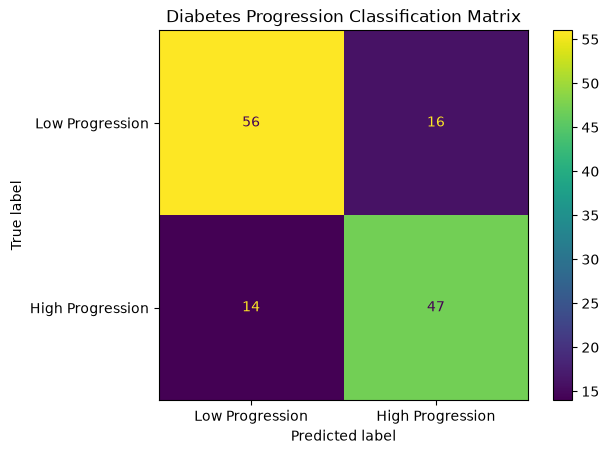

In [9]:
# Create binary classification target
median_progression = df['target'].median()
df['high_progression'] = (df['target'] > median_progression).astype(int)

X_clf = df.drop(columns=['target', 'high_progression'])
y_clf = df['high_progression']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42)

# Standardize features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)

# Train Logistic Regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train_c)

y_clf_pred = clf.predict(X_test_scaled)
acc = accuracy_score(y_test_c, y_clf_pred)
print(f"Classification Accuracy: {acc * 100:.2f}%")

# Display Confusion Matrix
cm = confusion_matrix(y_test_c, y_clf_pred)
ConfusionMatrixDisplay(cm, display_labels=['Low Progression', 'High Progression']).plot()
plt.title('Diabetes Progression Classification Matrix')
plt.show()

### 💬 Reflection Question 2.1
Examine the confusion matrix above. How balanced are the predictions between Low and High Progression? What might account for any misclassifications?

---
# Section 3: Hierarchical Agglomerative Clustering

In unsupervised learning, we group observations without using predefined ground-truth labels. Hierarchical Agglomerative Clustering builds a nested tree structure (dendrogram) based on pairwise distances.

### Code Example 3.1: Standardisation and Dendrogram Plotting
Distance metrics are sensitive to variable scales. Therefore, we standardize the numeric features before clustering.

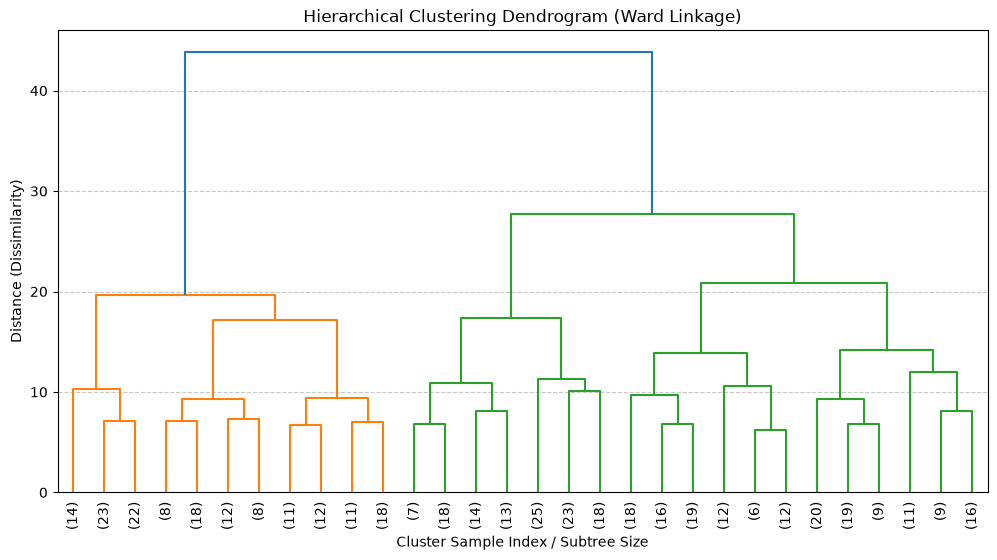

In [10]:
# Select numerical features (excluding targets)
features = df.drop(columns=['target', 'high_progression'])

# Scale dataset
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Perform Hierarchical Clustering using Ward linkage
linked_ward = linkage(scaled_features, method='ward')

# Plot Dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked_ward, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10.)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Cluster Sample Index / Subtree Size')
plt.ylabel('Distance (Dissimilarity)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### ✏️ Exercise 3.1
Change the linkage method in the code below from `'ward'` to **`'complete'`**. Run the cell and observe how the structure of the dendrogram changes.

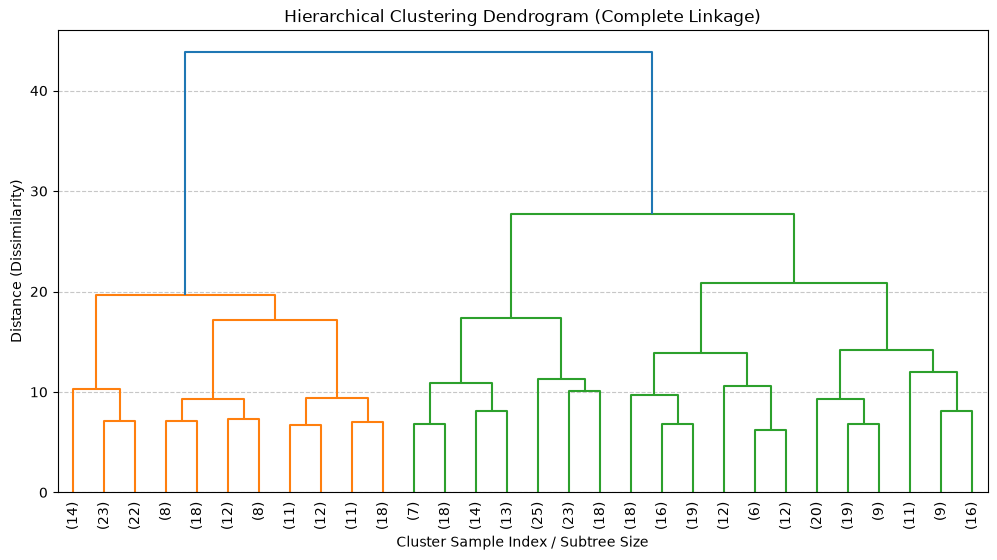

In [11]:
# --- YOUR CODE HERE ---
# Change method='ward' to method='complete'
linked_complete = linkage(scaled_features, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked_complete, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10.)
plt.title('Hierarchical Clustering Dendrogram (Complete Linkage)')
plt.xlabel('Cluster Sample Index / Subtree Size')
plt.ylabel('Distance (Dissimilarity)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Code Example 3.2: Cutting the Dendrogram into Clusters
We can cut the dendrogram to form $k=2$ distinct patient health clusters and compare them against actual high vs low progression categories.

In [12]:
# Extract 2 clusters from the Ward linkage tree
cluster_labels = fcluster(linked_ward, t=2, criterion='maxclust')

# Assign cluster IDs to the dataframe
df['Cluster_ID'] = cluster_labels

# Map target integer labels to actual names
df['Progression_Category'] = df['high_progression'].map({0: 'Low Progression', 1: 'High Progression'})

# Compare cluster IDs with ground-truth progression category
pd.crosstab(df['Progression_Category'], df['Cluster_ID'], rownames=['Actual Category'], colnames=['Assigned Cluster'])

Assigned Cluster,1,2
Actual Category,,
High Progression,37,184
Low Progression,120,101


### 💬 Reflection Question 3.1
Based on the cross-tabulation table above, how well did the unsupervised clustering group patients according to their progression level? What factors might explain why cluster boundaries do or do not line up perfectly with high/low disease progression?

---
# Summary & Final Checklist

Congratulations on completing the assessment! Check that you have:
- [ ] Completed all code modifications in **Exercises 1.1, 1.2, 2.1, and 3.1**.
- [ ] Saved output plots and verified that they appear in your Google Drive assessment folder.
- [ ] Answered all text reflection questions in markdown.